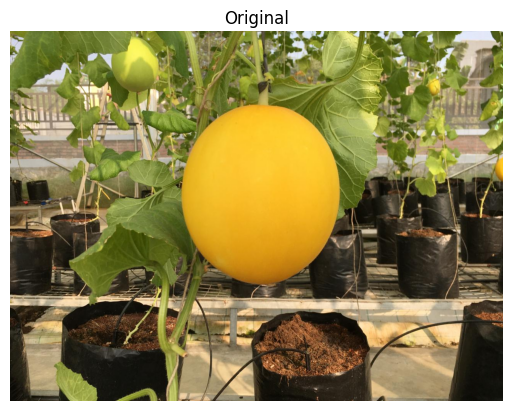

In [185]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar 
img_bgr = cv2.imread("melon.jpeg")

# BGR → RGB
img_rgb = img_bgr[:, :, ::-1]

# Split RGB
R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")
plt.show()

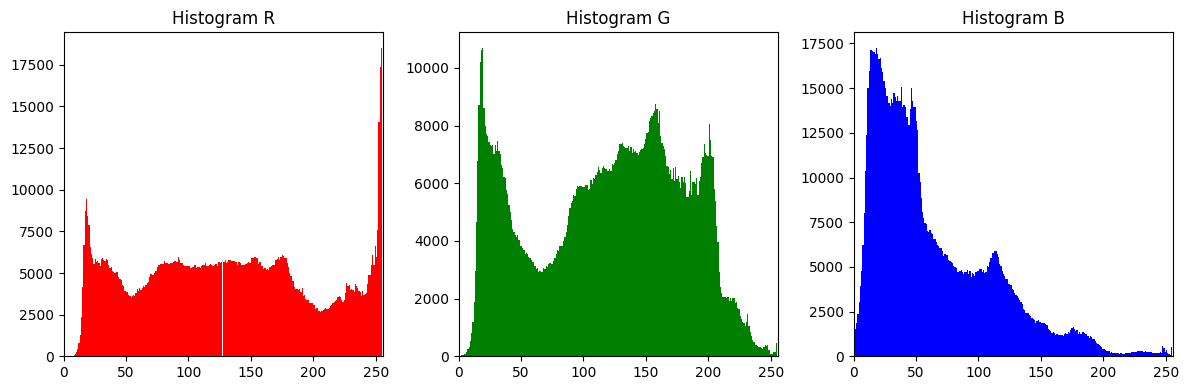

In [186]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(R.ravel(), bins=256, color='red')
plt.title("Histogram R")
plt.xlim([0,256])

plt.subplot(1,3,2)
plt.hist(G.ravel(), bins=256, color='green')
plt.title("Histogram G")
plt.xlim([0,256])

plt.subplot(1,3,3)
plt.hist(B.ravel(), bins=256, color='blue')
plt.title("Histogram B")
plt.xlim([0,256])

plt.tight_layout()
plt.show()

In [187]:
def rgb_to_hsv(img):

    img = img.astype(np.float32) / 255.0
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    Cmax = np.maximum(np.maximum(R, G), B)
    Cmin = np.minimum(np.minimum(R, G), B)
    delta = Cmax - Cmin

    H = np.zeros_like(Cmax)
    S = np.zeros_like(Cmax)
    V = Cmax

    # Hue
    mask = delta != 0

    idx = (Cmax == R) & mask
    H[idx] = (60 * ((G[idx] - B[idx]) / delta[idx]) % 360)

    idx = (Cmax == G) & mask
    H[idx] = (60 * ((B[idx] - R[idx]) / delta[idx]) + 120)

    idx = (Cmax == B) & mask
    H[idx] = (60 * ((R[idx] - G[idx]) / delta[idx]) + 240)

    # Saturation
    S[Cmax != 0] = delta[Cmax != 0] / Cmax[Cmax != 0]

    # Scaling ke format OpenCV
    H = (H / 2).astype(np.uint8)      # 0–179
    S = (S * 255).astype(np.uint8)
    V = (V * 255).astype(np.uint8)

    hsv = np.stack([H,S,V], axis=2)
    return hsv

hsv_img = rgb_to_hsv(img_rgb)
H_channel, S_channel, V_channel = cv2.split(hsv_img)

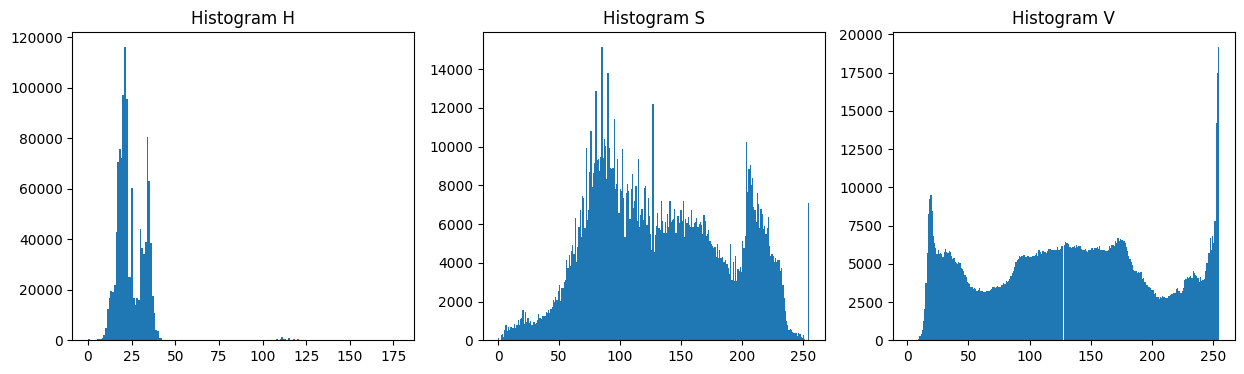

In [188]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(H_channel.ravel(), bins=180)
plt.title("Histogram H")

plt.subplot(1,3,2)
plt.hist(S_channel.ravel(), bins=256)
plt.title("Histogram S")

plt.subplot(1,3,3)
plt.hist(V_channel.ravel(), bins=256)
plt.title("Histogram V")

plt.show()

In [189]:
def rgb_to_lab(img):

    img = img.astype(np.float32) / 255.0
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    # RGB → XYZ
    X = 0.4124*R + 0.3576*G + 0.1805*B
    Y = 0.2126*R + 0.7152*G + 0.0722*B
    Z = 0.0193*R + 0.1192*G + 0.9505*B

    # Normalisasi D65
    X /= 0.95047
    Y /= 1.00000
    Z /= 1.08883

    # Fungsi f(t)
    def f(t):
        mask = t > 0.008856
        t[mask] = t[mask] ** (1/3)
        t[~mask] = (7.787 * t[~mask]) + (16/116)
        return t

    fx = f(X)
    fy = f(Y)
    fz = f(Z)

    L = (116 * fy) - 16
    a = 500 * (fx - fy)
    b = 200 * (fy - fz)

    # Scaling ke 0-255
    L = (L * 255 / 100)
    a = a + 128
    b = b + 128

    lab = np.stack([L, a, b], axis=2)
    lab = np.clip(lab, 0, 255).astype(np.uint8)

    return lab

lab_img = rgb_to_lab(img_rgb)
L_channel, a_channel, b_channel = cv2.split(lab_img)

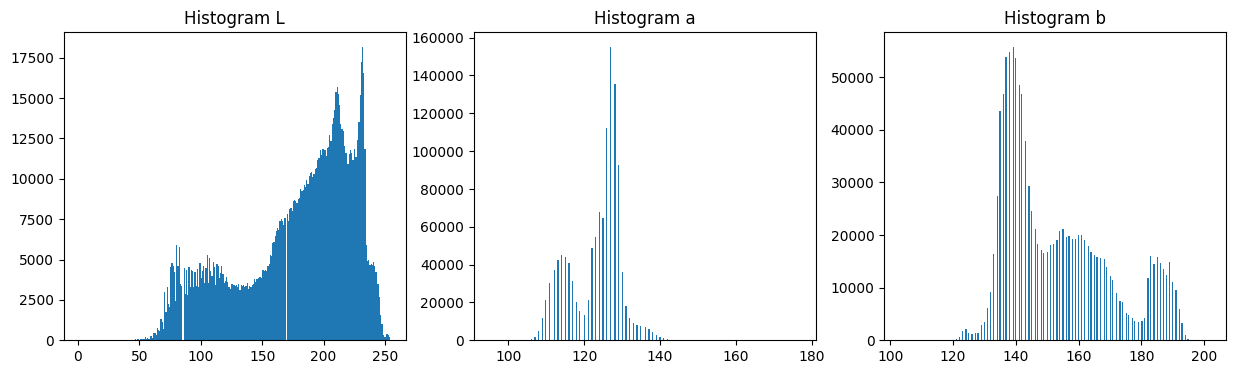

In [190]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(L_channel.ravel(), bins=256)
plt.title("Histogram L")

plt.subplot(1,3,2)
plt.hist(a_channel.ravel(), bins=256)
plt.title("Histogram a")

plt.subplot(1,3,3)
plt.hist(b_channel.ravel(), bins=256)
plt.title("Histogram b")

plt.show()

In [191]:
lower = np.array([15, 150, 150])
upper = np.array([25, 255, 255])

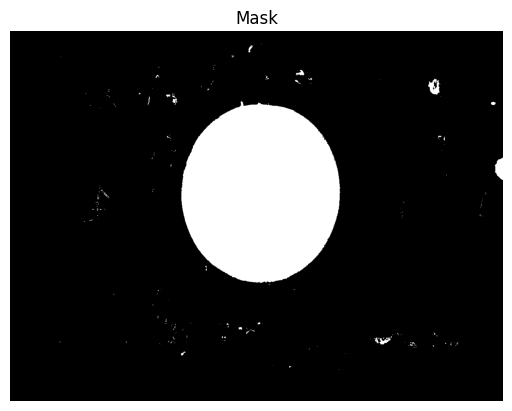

In [192]:
mask = cv2.inRange(hsv_img, lower, upper)

plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis("off")
plt.show()

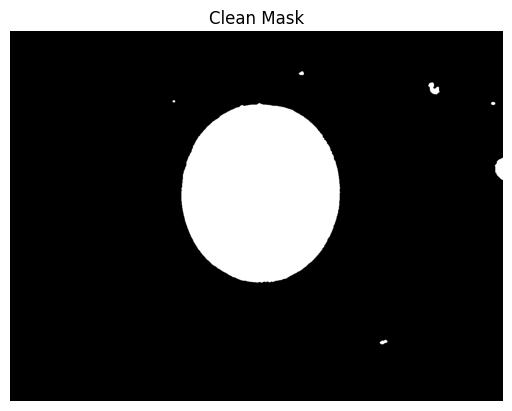

In [193]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)) # jadi bulat (ellipse)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel) # hapus noise luar
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) # hapus noise dalam

plt.imshow(mask, cmap='gray')
plt.title("Clean Mask")
plt.axis("off")
plt.show()

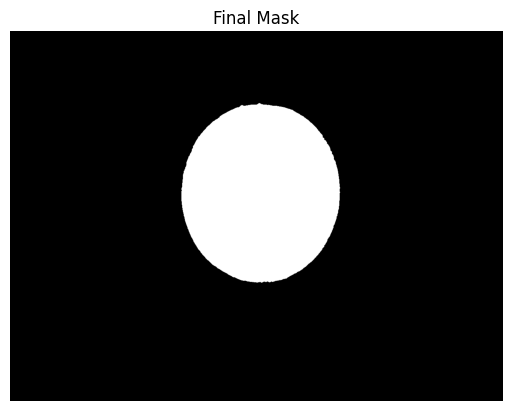

In [194]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # ambil objek putih di mask

largest = max(contours, key=cv2.contourArea) # ambil objek mask terbesar

clean_mask = np.zeros_like(mask)
cv2.drawContours(clean_mask, [largest], -1, 255, -1) # gambar ulang contour melon

plt.imshow(clean_mask, cmap='gray')
plt.title("Final Mask")
plt.axis("off")
plt.show()

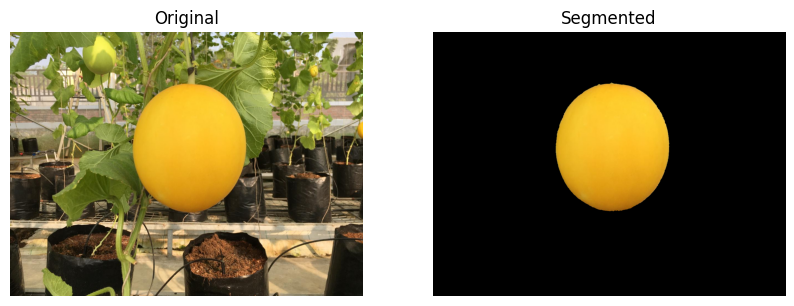

In [195]:
result = cv2.bitwise_and(img_rgb, img_rgb, mask=clean_mask) # ambil bagian yang dimask dan disamakan dari gambar original

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Segmented")
plt.axis("off")

plt.show()